In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflow.keras
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv
/kaggle/input/datasets/aminsed/test-4-json/test (4).json


In [7]:
import json
with open("/kaggle/input/datasets/aminsed/test-4-json/test (4).json","r") as f:
    loss_history = json.load(f)
    newl = {}
    for k in loss_history.keys():
        newl[int(k)] = loss_history[k]
    loss_history = newl
    new_entry = max(loss_history.keys())+1

In [8]:
new_entry

22

In [ ]:
loss_history={}
new_entry=0

In [9]:
df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")

In [10]:
tf.random.set_seed(42)
np.random.seed(42)

In [11]:
print(df.shape)
df.head()

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
X,y = df.iloc[:,1:],df.iloc[:,0]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [13]:
w = int(np.sqrt(df.shape[1]-1))

In [115]:
X_train = np.reshape(X_train,(-1,w,w,1)) / 255.0
X_test = np.reshape(X_test,(-1,w,w,1)) / 255.0
X = np.reshape(X,(-1,w,w,1)) / 255.0

In [116]:
tf.random.set_seed(42)
np.random.seed(42)
config = {
    "batch_size": 128,
    "epochs": 32,
    
    "lr": 2e-3,
    "patience": 5,
    "min_delta": 1e-3,
    "earlyStopping": True,
    
    "activation": "gelu",
    "kernel_initializer": "he_normal",
    
    "pool_size": (2,2),
    "padding": "same" #valid
}

In [117]:
model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(w,w,1)),
    tf.keras.layers.Conv2D(filters=8,kernel_size=(3,3),kernel_initializer=config["kernel_initializer"],activation=config["activation"],padding=config["padding"]),
    tf.keras.layers.MaxPool2D(pool_size=config["pool_size"]),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv2D(filters=16,kernel_size=(3,3),kernel_initializer=config["kernel_initializer"],activation=config["activation"],padding=config["padding"]),
    tf.keras.layers.MaxPool2D(pool_size=config["pool_size"]),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    #MLP
    # tf.keras.layers.Dense(128,activation="relu",kernel_initializer=config["kernel_initializer"]),
    tf.keras.layers.Dense(64,activation="relu",kernel_initializer=config["kernel_initializer"]),
    tf.keras.layers.Dense(10)
])

model_1.compile(
    tf.keras.optimizers.Adam(config["lr"]),
    tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

model_1.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,138 (203.66 KB)

 Trainable params: 52,138 (203.66 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
print(f"{new_entry}:")
print(config)
hist_1 = model_1.fit(
    X_train,
    y_train,
    batch_size=config["batch_size"],
    epochs=config["epochs"],
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=config["patience"],min_delta=config["min_delta"],restore_best_weights=True)
    ] if config["earlyStopping"] else []
)
eval_1 = model_1.evaluate(X_test,y_test)
loss_history[new_entry] = {"params": config,"history":hist_1.history,"evaluate":eval_1}
new_entry+=1
print(eval_1)

32:
{'batch_size': 128, 'epochs': 32, 'lr': 0.002, 'patience': 5, 'min_delta': 0.001, 'earlyStopping': True, 'activation': 'gelu', 'kernel_initializer': 'he_normal', 'pool_size': (2, 2), 'padding': 'same'}
Epoch 1/32
263/263 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.7347 - loss: 0.8006 - val_accuracy: 0.9601 - val_loss: 0.1272
Epoch 2/32
263/263 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.9495 - loss: 0.1625 - val_accuracy: 0.9701 - val_loss: 0.0898
Epoch 3/32
263/263 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.9620 - loss: 0.1234 - val_accuracy: 0.9755 - val_loss: 0.0775
Epoch 4/32
263/263 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.9708 - loss: 0.0961 - val_accuracy: 0.9808 - val_loss: 0.0590
Epoch 5/32
263/263 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.9749 - loss: 0.0798 - val_accuracy: 0.9813 - val_loss: 0.0595
Epoch 6/32
263/263 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.9781 - loss: 0.0691 - val_accuracy: 0.9851 - val_loss: 0.0526
Epoch 7/32
263

8: [0.1772848665714264, 0.9717857241630554]
16: [0.2950756251811981, 0.9599999785423279]
21: [0.08623015135526657, 0.9859523773193359]
26: [0.07024875283241272, 0.9838095307350159]
27: [0.04492102190852165, 0.9867857098579407]
31: [0.04295087978243828, 0.9866666793823242]


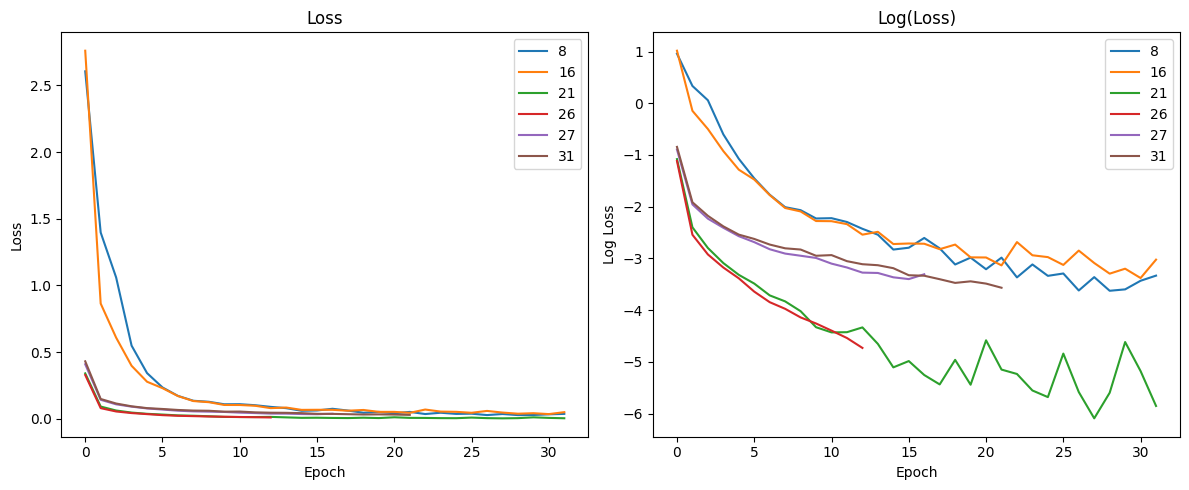

In [89]:
excluded_runs = {4,5,7,10,11,12,13,14,15,17,18,19,6,9,20,22,23,24,25,28,29,30}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot — actual loss
for i in loss_history.keys():
    if i in excluded_runs: continue
    loss_vals = loss_history[i]['history']['loss']
    axes[0].plot(loss_vals, label=i)

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()


# Right plot — log loss
for i in loss_history.keys():
    if i in excluded_runs: continue
    print(f"{i}: {loss_history[i].get('evaluate',[])}")
    loss_vals = loss_history[i]['history']['loss']
    axes[1].plot(np.log(loss_vals), label=i)

axes[1].set_title("Log(Loss)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Log Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

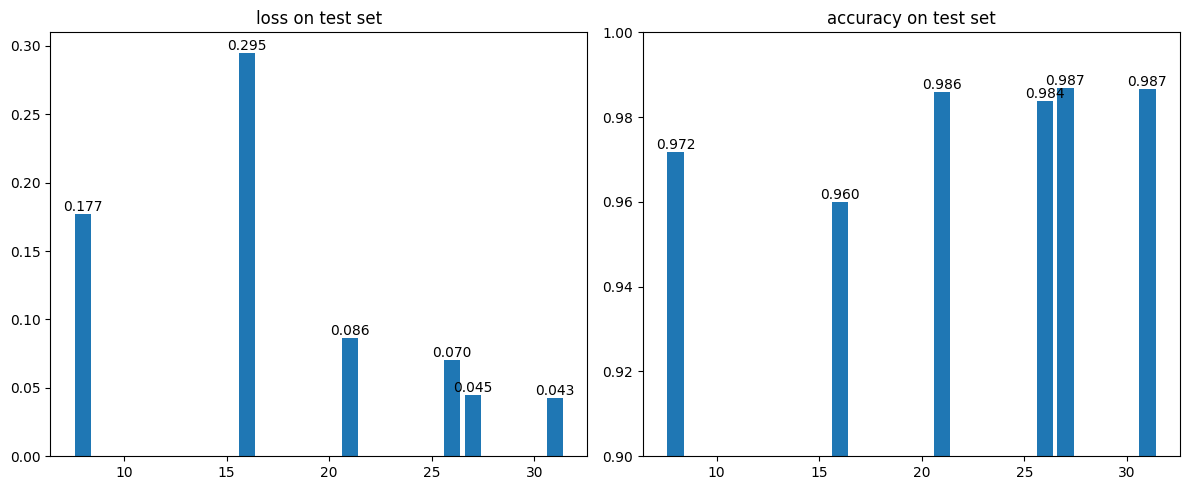

In [90]:
x,h1,h2=[],[],[]
for i in loss_history.keys():
    if i in excluded_runs: continue
    x.append(i)
    h1.append(loss_history[i].get('evaluate',[0,0])[0])
    h2.append(loss_history[i].get('evaluate',[0,0])[1])
    # print(f"{i}: {}")

fig,axes = plt.subplots(1,2,figsize=(12,5))
bars1 = axes[0].bar(x,h1)
axes[0].set_title("loss on test set")

axes[0].bar_label(bars1, fmt='%.3f')


bars2 = axes[1].bar(x,h2)
axes[1].set_title("accuracy on test set")
axes[1].bar_label(bars2, fmt='%.3f')
axes[1].set_ylim(0.9, 1)

plt.tight_layout()
plt.show()

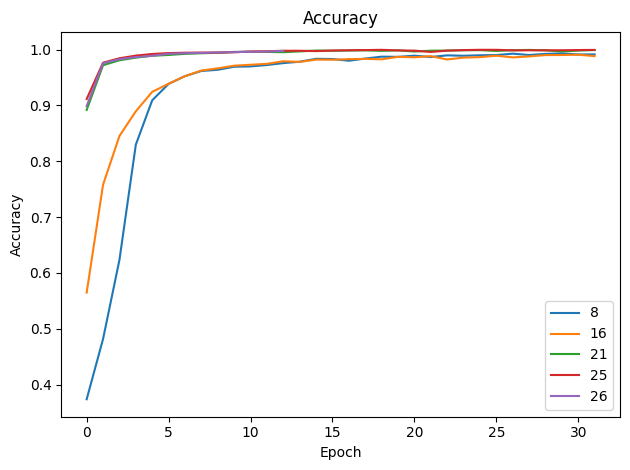

In [60]:
for i in loss_history.keys():
    if i in excluded_runs: continue
    acc_vals = loss_history[i]['history'].get('accuracy',[])
    plt.plot(acc_vals, label=i)

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

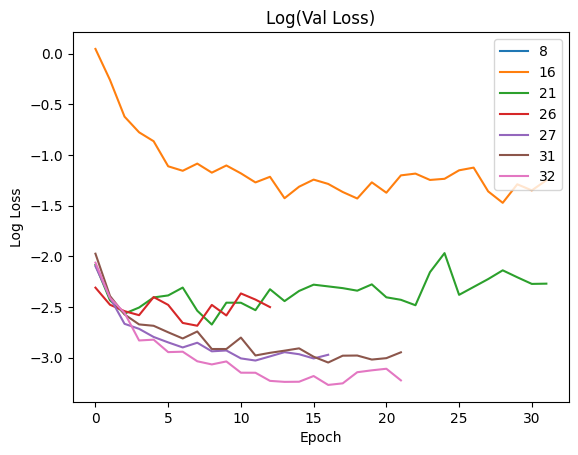

In [119]:
for i in loss_history.keys():
    if i in excluded_runs: continue
    loss_vals = loss_history[i]['history'].get("val_loss",[])
    plt.plot(np.log(loss_vals), label=i)

plt.title("Log(Val Loss)")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()

In [91]:
# with open("/kaggle/working/test.json","w") as f:
#     json.dump(loss_history,f)

In [120]:
test_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/test.csv")

In [121]:
test_df = np.reshape(test_df,(-1,w,w,1))

In [122]:
model_argmax = np.argmax(model_1(test_df),1)

In [126]:
model_df = pd.DataFrame({"ImageId":range(1,test_df.shape[0]+1),"Label":model_argmax})

In [127]:
model_df

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


In [128]:
model_df.to_csv("submission.csv",index=False)